# Fraud Detection — Baseline Model Training

This notebook:
1. Generates a synthetic training dataset using the same code as the producer + predictor
2. Trains a LogisticRegression baseline model
3. Logs parameters, metrics, and artifacts to MLflow
4. Exports `model.joblib` for the predictor service
5. Registers the model in MLflow Model Registry

**Key principle**: We import `transaction.py` and `features.py` directly — the model trains on the exact same features it will see at inference time. No train/serve skew.

## 1. Setup — Imports & Paths

In [1]:
import sys
import json
import time
import random
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.sklearn
import fakeredis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

PROJECT_ROOT = Path.cwd().parent

# Import producer's transaction module (avoid app namespace collision)
sys.path.insert(0, str(PROJECT_ROOT / "services" / "producer"))
import app.transaction as transaction_mod
sys.path.pop(0)

# Import predictor's features module
sys.path.insert(0, str(PROJECT_ROOT / "services" / "predictor"))
# Reload app package to point at predictor's app/
if "app" in sys.modules:
    del sys.modules["app"]
import app.features as features_mod
sys.path.pop(0)

generate_transaction = transaction_mod.generate_transaction
FEATURE_NAMES = features_mod.FEATURE_NAMES
update_user_features = features_mod.update_user_features
get_user_features = features_mod.get_user_features

MODEL_DIR = PROJECT_ROOT / "services" / "predictor" / "model"
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.joblib"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model output: {MODEL_PATH}")
print(f"Feature names: {FEATURE_NAMES}")

C:\Users\USER\Documents\Database\Personal Projects\fraud_detection\.venv\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


Project root: C:\Users\USER\Documents\Database\Personal Projects\fraud_detection
Model output: C:\Users\USER\Documents\Database\Personal Projects\fraud_detection\services\predictor\model\model.joblib
Feature names: ['txn_count_1h', 'txn_count_24h', 'avg_amount_24h', 'amount_vs_avg_ratio', 'amount', 'hour_of_day', 'day_of_week']


## 2. Generate Synthetic Dataset

We generate transactions using `generate_transaction()` from the producer, then compute features using `features.py` from the predictor with a **fakeredis** instance. This simulates what the predictor does in real-time, but offline.

Each user accumulates history as we iterate, so later transactions for the same user have richer features (higher `txn_count`, meaningful `avg_amount`, etc.).

In [2]:
N_SAMPLES = 20_000
random.seed(42)
np.random.seed(42)

redis_client = fakeredis.FakeRedis()

rows = []
base_ts = time.time() - 86400  # start 24h ago so windows are meaningful

for i in range(N_SAMPLES):
    txn = generate_transaction(drift_mode=False)
    ts = base_ts + (i * 2)  # 2 seconds apart

    user_id = txn["user_id"]
    amount = txn["amount"]
    txn_id = txn["transaction_id"]

    # Update Redis with this transaction (write path)
    update_user_features(redis_client, user_id, txn_id, amount, timestamp=ts)

    # Compute features (read path) — same code as the predictor
    features = get_user_features(redis_client, user_id, amount, timestamp=ts)

    rows.append({
        **features,
        "amount": amount,
        "hour_of_day": txn["hour_of_day"],
        "day_of_week": txn["day_of_week"],
        "is_fraud": int(txn["is_fraud"]),
    })

df = pd.DataFrame(rows)
print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean():.3%}")
df.head(10)

Dataset shape: (20000, 8)
Fraud rate: 1.330%


,txn_count_1h,txn_count_24h,avg_amount_24h,amount_vs_avg_ratio,amount,hour_of_day,day_of_week,is_fraud
0,1.0,1.0,38.70,1.0,38.70,20,4,0
1,1.0,1.0,37.60,1.0,37.60,20,4,0
2,1.0,1.0,35.98,1.0,35.98,20,4,0
3,1.0,1.0,50.19,1.0,50.19,20,4,0
4,1.0,1.0,57.19,1.0,57.19,20,4,1
5,1.0,1.0,165.85,1.0,165.85,20,4,0
6,1.0,1.0,107.06,1.0,107.06,20,4,0
7,1.0,1.0,35.14,1.0,35.14,20,4,0
8,1.0,1.0,3.25,1.0,3.25,20,4,0
9,1.0,1.0,24.36,1.0,24.36,20,4,0


## 3. Explore the Data

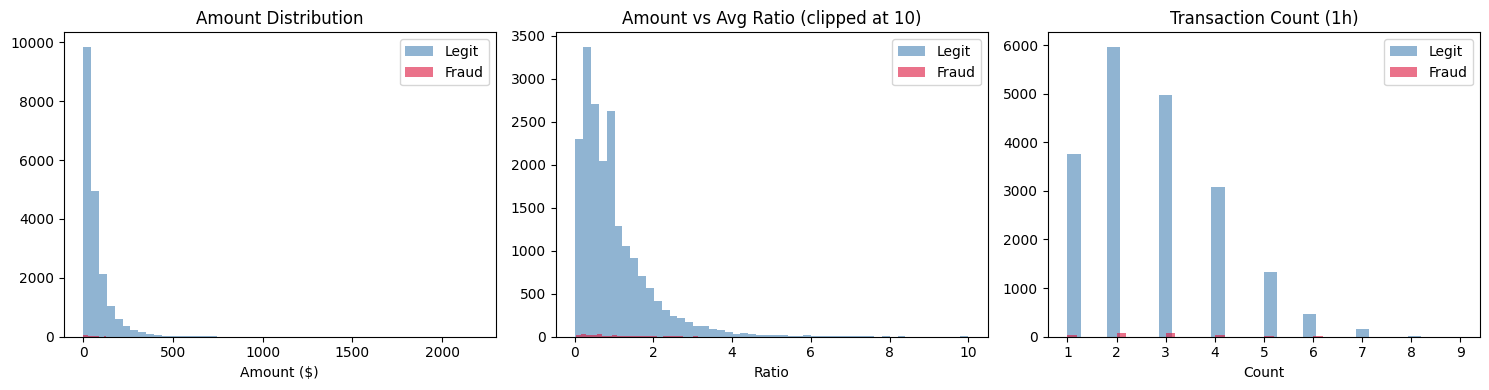


Feature statistics:


,txn_count_1h,txn_count_24h,avg_amount_24h,amount_vs_avg_ratio,amount,hour_of_day,day_of_week,amount
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.0,20000.0,20000.00
mean,2.72,10.99,74.36,1.00,75.11,20.0,4.0,75.11
std,1.33,6.56,40.13,0.96,99.74,0.0,0.0,99.74
min,1.00,1.00,2.46,0.01,1.03,20.0,4.0,1.03
25%,2.00,5.75,52.23,0.37,23.11,20.0,4.0,23.11
50%,3.00,10.50,68.33,0.75,44.92,20.0,4.0,44.92
75%,4.00,16.00,87.74,1.29,88.53,20.0,4.0,88.53
max,9.00,36.00,1397.13,14.91,2190.13,20.0,4.0,2190.13


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Amount distribution by label
for label, color in [(0, "steelblue"), (1, "crimson")]:
    subset = df[df["is_fraud"] == label]
    axes[0].hist(subset["amount"], bins=50, alpha=0.6, label=f"{'Fraud' if label else 'Legit'}", color=color)
axes[0].set_title("Amount Distribution")
axes[0].set_xlabel("Amount ($)")
axes[0].legend()

# Amount vs avg ratio
for label, color in [(0, "steelblue"), (1, "crimson")]:
    subset = df[df["is_fraud"] == label]
    axes[1].hist(subset["amount_vs_avg_ratio"].clip(upper=10), bins=50, alpha=0.6,
                 label=f"{'Fraud' if label else 'Legit'}", color=color)
axes[1].set_title("Amount vs Avg Ratio (clipped at 10)")
axes[1].set_xlabel("Ratio")
axes[1].legend()

# Txn count 1h
for label, color in [(0, "steelblue"), (1, "crimson")]:
    subset = df[df["is_fraud"] == label]
    axes[2].hist(subset["txn_count_1h"], bins=30, alpha=0.6,
                 label=f"{'Fraud' if label else 'Legit'}", color=color)
axes[2].set_title("Transaction Count (1h)")
axes[2].set_xlabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nFeature statistics:")
df[FEATURE_NAMES + ["amount"]].describe().round(2)

## 4. Train/Test Split & Model Training

We use the 4 rolling aggregate features from `features.py` plus `amount`, `hour_of_day`, and `day_of_week` as raw features. The model feature order is defined explicitly so the predictor can reconstruct the same vector.

In [4]:
# Model features — FEATURE_NAMES from features.py is the single source of truth
# It includes both rolling aggregates (from Redis) and raw transaction fields
MODEL_FEATURES = FEATURE_NAMES
TARGET = "is_fraud"

X = df[MODEL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean():.2%} fraud)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean():.2%} fraud)")
print(f"Model features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}")

Train: 16000 samples (1.33% fraud)
Test:  4000 samples (1.32% fraud)
Model features (7): ['txn_count_1h', 'txn_count_24h', 'avg_amount_24h', 'amount_vs_avg_ratio', 'amount', 'hour_of_day', 'day_of_week']


In [5]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # handle class imbalance (~1.2% fraud)
    random_state=42,
    solver="lbfgs",
)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

for name, value in metrics.items():
    print(f"  {name:>12s}: {value:.4f}")

      accuracy: 0.5978
     precision: 0.0101
        recall: 0.3019
            f1: 0.0195
       roc_auc: 0.4661


## 5. Confusion Matrix

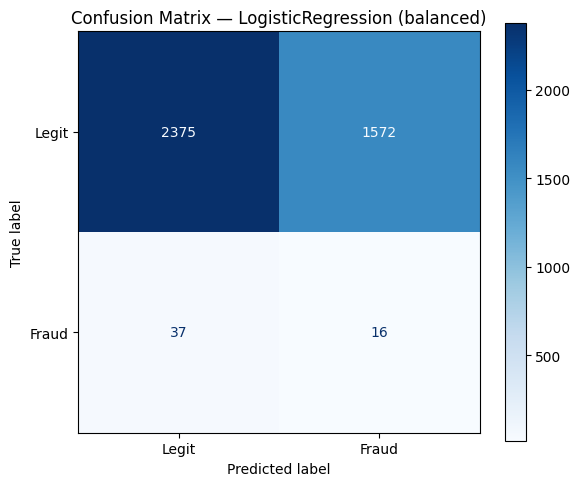

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — LogisticRegression (balanced)")
plt.tight_layout()
plt.show()

## 6. Log to MLflow & Export Model

We log everything to the MLflow server running in Docker (port 5001 on host). The feature schema is saved as a JSON artifact so we can audit train/serve consistency later.

In [7]:
# Point at the MLflow server (Docker exposes 5001 on host)
mlflow.set_tracking_uri("http://localhost:5001")
mlflow.set_experiment("fraud_detection")

with mlflow.start_run(run_name="logistic_regression_baseline") as run:
    # --- Parameters ---
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("solver", "lbfgs")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("n_samples", N_SAMPLES)
    mlflow.log_param("n_features", len(MODEL_FEATURES))
    mlflow.log_param("test_size", 0.2)

    # --- Metrics ---
    for name, value in metrics.items():
        mlflow.log_metric(name, value)

    # --- Feature schema artifact ---
    feature_schema = {
        "feature_names": MODEL_FEATURES,
        "feature_types": {col: str(df[col].dtype) for col in MODEL_FEATURES},
    }
    schema_path = MODEL_DIR / "feature_schema.json"
    schema_path.write_text(json.dumps(feature_schema, indent=2))
    mlflow.log_artifact(str(schema_path), artifact_path="schema")

    # --- Log the sklearn model ---
    mlflow.sklearn.log_model(
        model,
        artifact_path="model",
        registered_model_name="fraud_detection_baseline",
    )

    # --- Export joblib for the predictor container ---
    joblib.dump(model, MODEL_PATH)
    mlflow.log_artifact(str(MODEL_PATH), artifact_path="model_export")

    run_id = run.info.run_id
    print(f"MLflow run ID: {run_id}")
    print(f"Model exported to: {MODEL_PATH}")
    print(f"View at: http://localhost:5001/#/experiments")

2026/03/06 22:27:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'fraud_detection_baseline' already exists. Creating a new version of this model...
2026/03/06 22:27:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud_detection_baseline, version 2


Created version '2' of model 'fraud_detection_baseline'.
2026/03/06 22:27:26 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


2026/03/06 22:27:26 INFO mlflow.tracking._tracking_service.client: 🏃 View run logistic_regression_baseline at: http://localhost:5001/#/experiments/1/runs/3c4823c04906451ebcefd9b37e4b1cb6.


2026/03/06 22:27:26 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5001/#/experiments/1.


MLflow run ID: 3c4823c04906451ebcefd9b37e4b1cb6
Model exported to: C:\Users\USER\Documents\Database\Personal Projects\fraud_detection\services\predictor\model\model.joblib
View at: http://localhost:5001/#/experiments


## 7. Verify Model Loads Correctly

Quick sanity check — load the exported joblib and confirm it produces the same predictions.

In [8]:
loaded_model = joblib.load(MODEL_PATH)
y_proba_loaded = loaded_model.predict_proba(X_test)[:, 1]

assert np.allclose(y_proba, y_proba_loaded), "Loaded model gives different predictions!"
print("Model loaded and verified — predictions match.")
print(f"Sample predictions (first 10): {y_proba_loaded[:10].round(4)}")

Model loaded and verified — predictions match.
Sample predictions (first 10): [0.4907 0.4656 0.489  0.5088 0.5041 0.4822 0.4713 0.5188 0.4689 0.5137]


## Next Steps

The model is now at `services/predictor/model/model.joblib`. To deploy it:

1. Rebuild the predictor: `docker compose up --build predictor -d`
2. The predictor will load the real model instead of returning the 0.5 fallback
3. Check MLflow UI at http://localhost:5001 to see the logged run, metrics, and registered model